In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib
import os

In [4]:
graph_folder = r"D:\Datascience_Internship\Prodigy_Task3\graphs"
model_folder = r"D:\Datascience_Internship\Prodigy_Task3\models"

os.makedirs(graph_folder, exist_ok=True)
os.makedirs(model_folder, exist_ok=True)

In [5]:
bank_small = pd.read_csv(
    r"D:\Datascience_Internship\Prodigy_Task3\bank\bank.csv",
    sep=";"
)

bank_full = pd.read_csv(
    r"D:\Datascience_Internship\Prodigy_Task3\bank\bank-full.csv",
    sep=";"
)

bank_additional_small = pd.read_csv(
    r"D:\Datascience_Internship\Prodigy_Task3\bank-additional\bank-additional.csv",
    sep=";"
)

bank_additional_full = pd.read_csv(
    r"D:\Datascience_Internship\Prodigy_Task3\bank-additional\bank-additional-full.csv",
    sep=";"
)

In [6]:
datasets = {
    "Bank Small": bank_small,
    "Bank Full": bank_full,
    "Bank Additional Small": bank_additional_small,
    "Bank Additional Full": bank_additional_full
}

for name, df in datasets.items():
    print("="*50)
    print(name)
    print(df.shape)
    print(df.head())
    print(df.info())

Bank Small
(4521, 17)
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (t

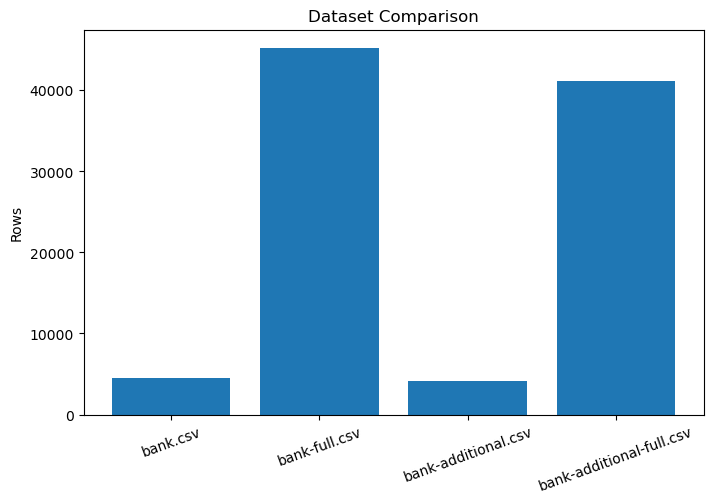

In [7]:
sizes = {
    "bank.csv": len(bank_small),
    "bank-full.csv": len(bank_full),
    "bank-additional.csv": len(bank_additional_small),
    "bank-additional-full.csv": len(bank_additional_full)
}

plt.figure(figsize=(8,5))
plt.bar(sizes.keys(), sizes.values())
plt.title("Dataset Comparison")
plt.ylabel("Rows")
plt.xticks(rotation=20)

plt.savefig(
    os.path.join(graph_folder,"Dataset_Comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
def train_model(df, name):

    data = df.copy()

    encoder = LabelEncoder()

    for col in data.columns:
        if data[col].dtype == "object":
            data[col] = encoder.fit_transform(data[col])

    X = data.drop("y", axis=1)
    y = data["y"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42,
        max_depth=6
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    print("\n",name)
    print("Accuracy :",accuracy_score(y_test,prediction))

    print(classification_report(y_test,prediction))

    cm = confusion_matrix(y_test,prediction)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues"
    )

    plt.title(name+" Confusion Matrix")

    plt.savefig(
        os.path.join(graph_folder,name+"_ConfusionMatrix.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.figure(figsize=(20,10))

    plot_tree(
        model,
        filled=True,
        feature_names=X.columns,
        class_names=["No","Yes"],
        fontsize=7
    )

    plt.title(name+" Decision Tree")

    plt.savefig(
        os.path.join(graph_folder,name+"_DecisionTree.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    importance = pd.Series(
        model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(10,6))

    importance.head(10).plot(kind="bar")

    plt.title(name+" Top Features")

    plt.savefig(
        os.path.join(graph_folder,name+"_FeatureImportance.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    joblib.dump(
        model,
        os.path.join(model_folder,name+"_DecisionTree.pkl")
    )

    return model


 Bank_Full
Accuracy : 0.8978215194072764
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.62      0.39      0.48      1091

    accuracy                           0.90      9043
   macro avg       0.77      0.68      0.71      9043
weighted avg       0.88      0.90      0.89      9043



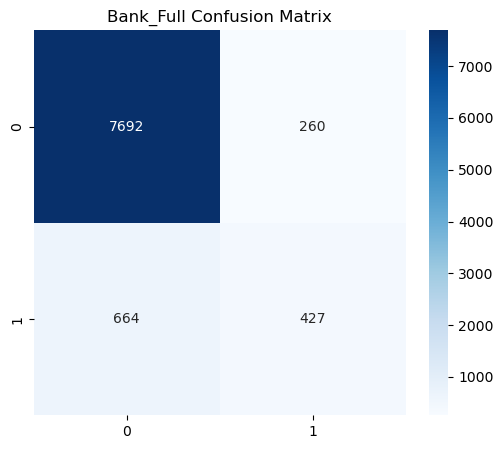

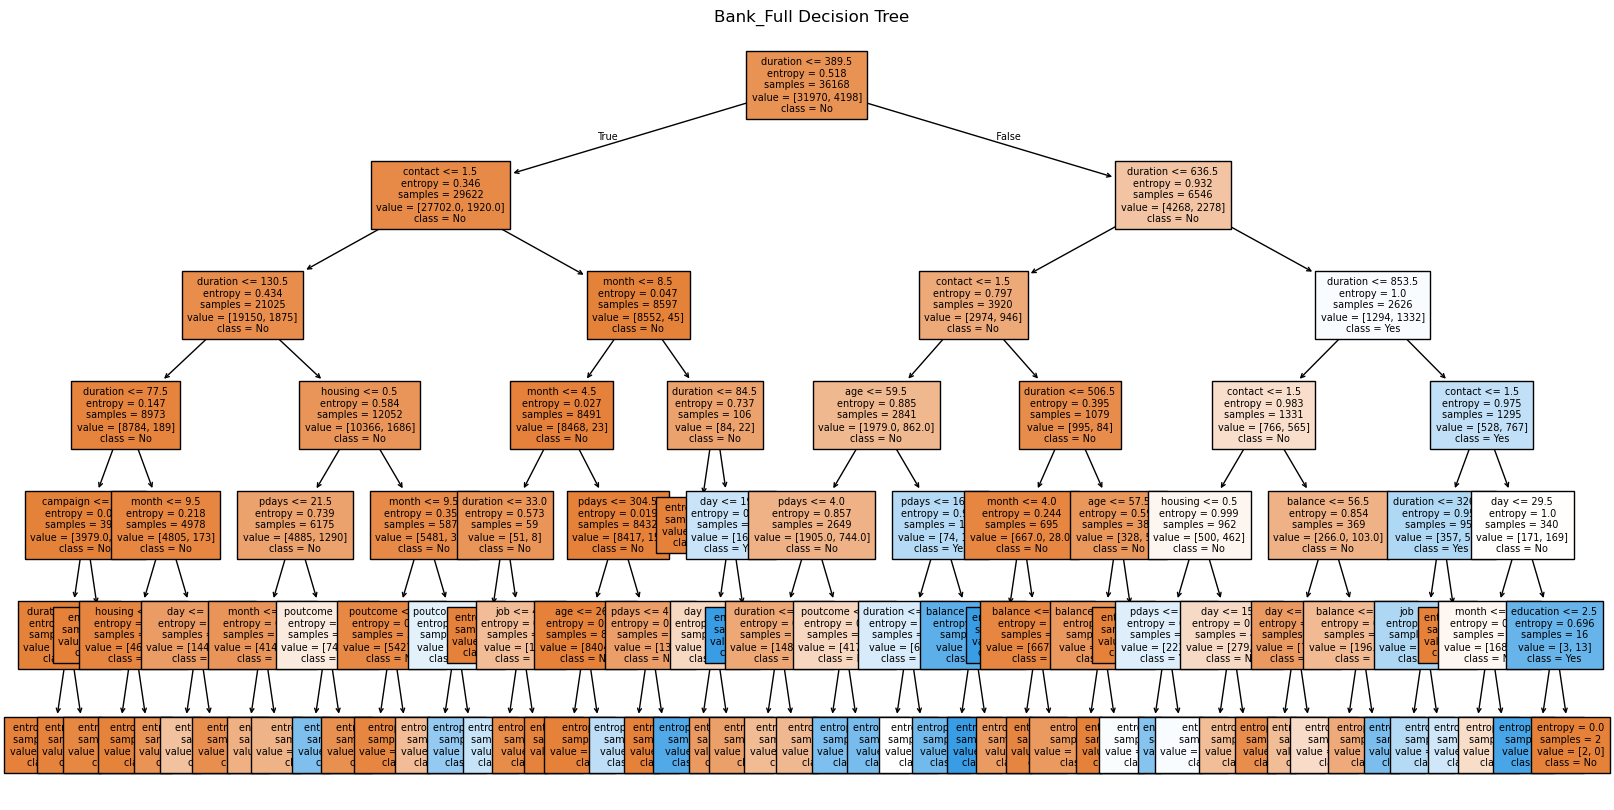

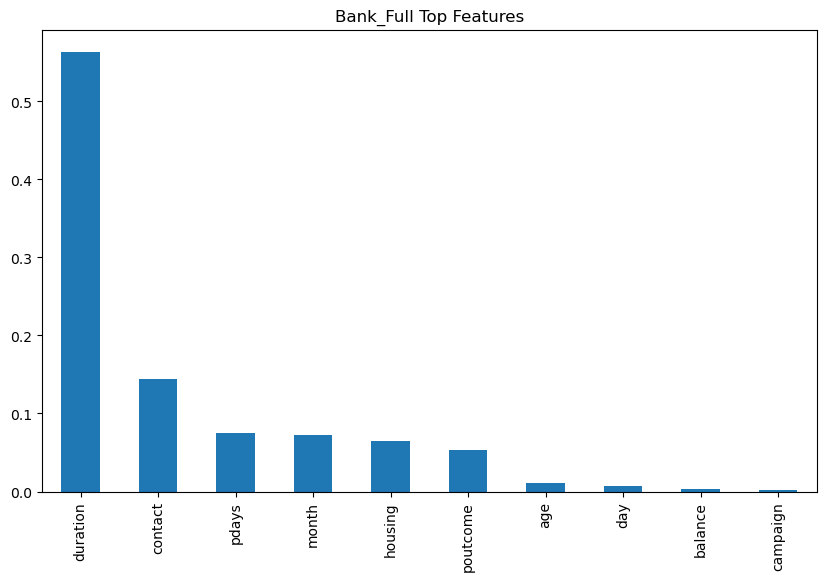


 Bank_Additional_Full
Accuracy : 0.913814032532168
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7303
           1       0.65      0.53      0.58       935

    accuracy                           0.91      8238
   macro avg       0.79      0.75      0.77      8238
weighted avg       0.91      0.91      0.91      8238



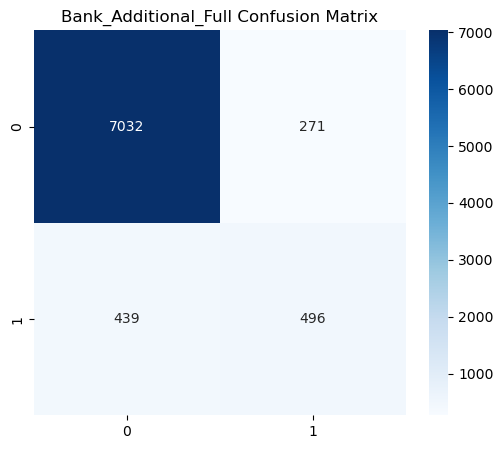

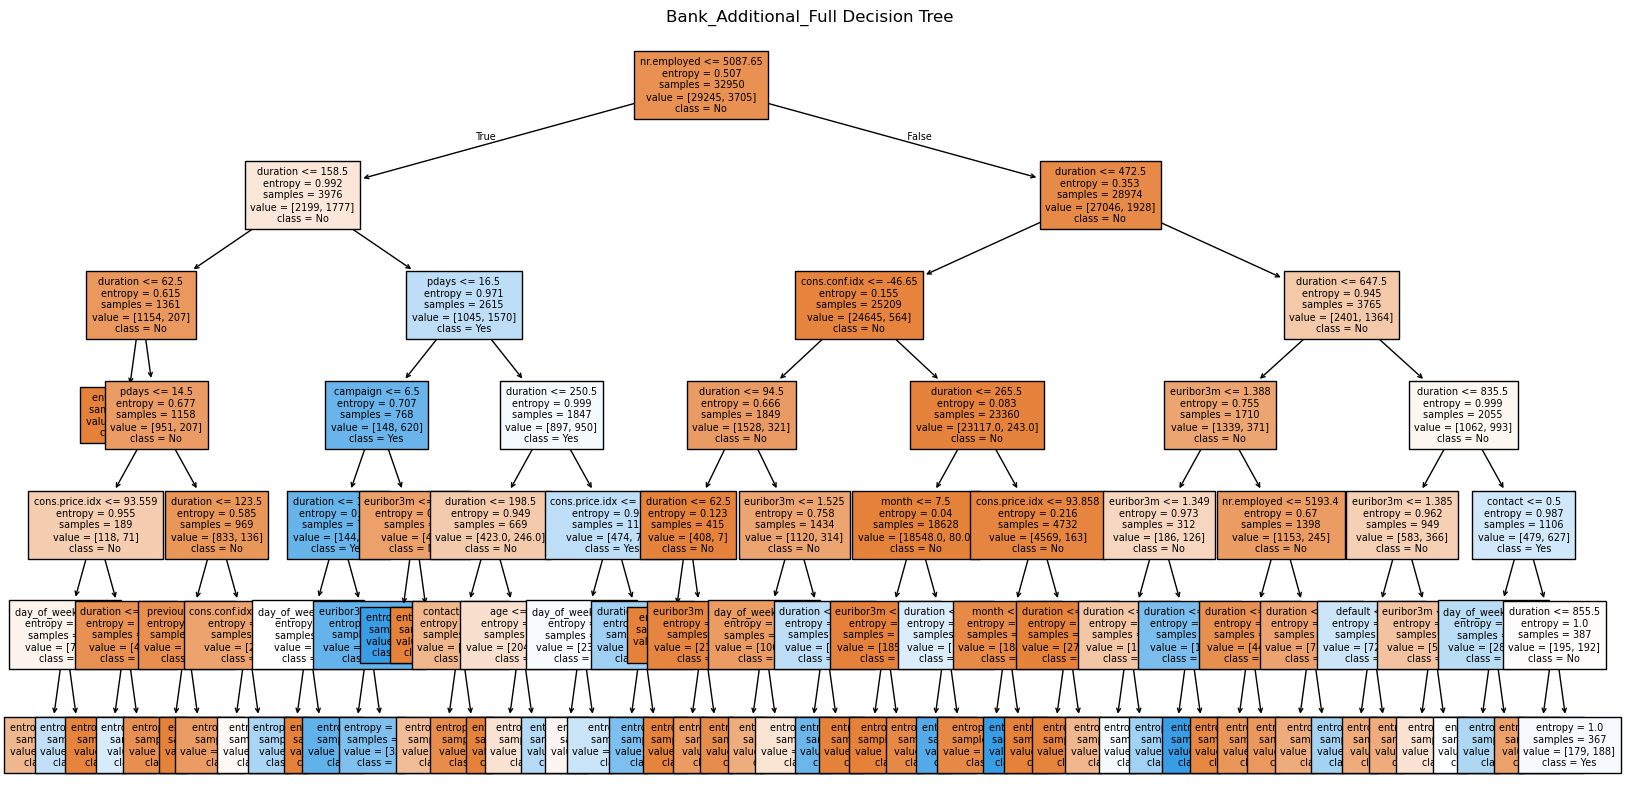

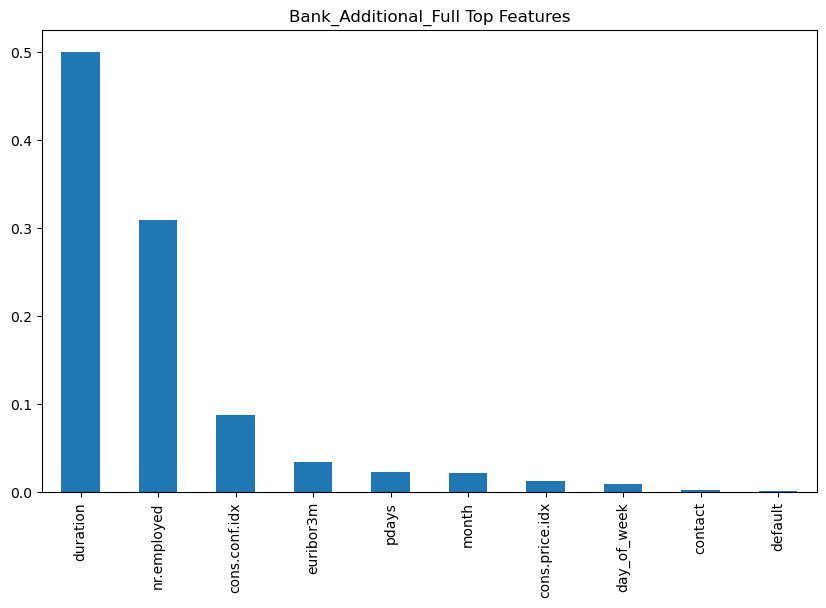

In [9]:
model1 = train_model(bank_full,"Bank_Full")

model2 = train_model(bank_additional_full,"Bank_Additional_Full")

In [10]:
print("="*50)
print("Model Comparison")
print("="*50)

print("Bank Full Model :", model1)
print("Bank Additional Full Model :", model2)

print("\nBoth models have been trained successfully.")

Model Comparison
Bank Full Model : DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)
Bank Additional Full Model : DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)

Both models have been trained successfully.


In [11]:
sample = bank_additional_full.iloc[[0]].copy()

actual = sample["y"].values[0]

sample = sample.drop("y", axis=1)

print("Actual Value :", actual)

Actual Value : no


In [12]:
import os

print("Saved Graphs")

for file in os.listdir(graph_folder):
    print(file)

print("\nSaved Models")

for file in os.listdir(model_folder):
    print(file)

Saved Graphs
Bank_Additional_Full_ConfusionMatrix.png
Bank_Additional_Full_DecisionTree.png
Bank_Additional_Full_FeatureImportance.png
Bank_Full_ConfusionMatrix.png
Bank_Full_DecisionTree.png
Bank_Full_FeatureImportance.png
Dataset_Comparison.png

Saved Models
Bank_Additional_Full_DecisionTree.pkl
Bank_Full_DecisionTree.pkl
